In [27]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [28]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 8, 'axis': 'z'}

In [29]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test8/rolling_z
['reference', 'info.json', 'target']


In [30]:
TARGET_VAR = 'pitch'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [15, 60], 'static': [65, 999999999]}
[65, 999999999]
[15, 60]


# IMPORTANDO DADOS

In [31]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df

,pitch,q2,q1,ay,roll,yaw,ax,wy,q0,time,q3,az,wz,wx,sample_time,la_pos_mon_d
0,0.004444,0.000984,0.7227,9.777,-1.615,0.006973,0.04649,-0.000246,-0.6912,2.384186e-07,-0.004016,0.4286,-0.000124,0.000072,805000000.0,0.3381
1,0.004440,0.000987,0.7227,9.777,-1.615,0.006981,0.04615,-0.000240,-0.6912,8.465290e-02,-0.004018,0.4283,-0.000110,0.000077,905000000.0,0.3482
2,0.004433,0.000992,0.7227,9.777,-1.615,0.006985,0.04615,0.000041,-0.6912,1.922421e-01,-0.004017,0.4278,0.000055,0.000382,5000000.0,0.3583
3,0.004429,0.001005,0.7227,9.777,-1.615,0.007015,0.04635,-0.000276,-0.6912,2.940345e-01,-0.004026,0.4289,0.000113,0.000479,105000000.0,0.3684
4,0.004421,0.001013,0.7226,9.777,-1.615,0.007034,0.04679,-0.000189,-0.6912,3.834641e-01,-0.004029,0.4296,-0.000031,0.000962,205000000.0,0.3785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,0.000172,0.006933,0.7229,9.776,-1.616,0.019350,0.05456,-0.000163,-0.6909,1.033927e+02,-0.006747,0.4466,0.000050,0.000717,205000000.0,2.3000
1035,0.000168,0.006942,0.7228,9.776,-1.616,0.019370,0.05472,-0.000168,-0.6910,1.034937e+02,-0.006754,0.4467,0.000223,0.000616,305000000.0,2.2960
1036,0.000198,0.006933,0.7228,9.776,-1.616,0.019370,0.04937,0.000007,-0.6910,1.035909e+02,-0.006766,0.4479,0.000195,0.000291,405000000.0,2.2920
1037,0.000221,0.006927,0.7228,9.775,-1.616,0.019380,0.04573,-0.000174,-0.6910,1.036941e+02,-0.006777,0.4474,0.000342,0.000434,505000000.0,2.2880


- Convertendo pra radianos

In [32]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,pitch,q2,q1,ay,roll,yaw,ax,wy,q0,time,q3,az,wz,wx,sample_time,la_pos_mon_d
0,0.254622,0.000984,0.7227,9.777,-92.532684,0.399523,0.04649,-0.014066,-0.6912,2.384186e-07,-0.004016,0.4286,-0.007110,0.004141,805000000.0,0.3381
1,0.254393,0.000987,0.7227,9.777,-92.532684,0.399982,0.04615,-0.013780,-0.6912,8.465290e-02,-0.004018,0.4283,-0.006325,0.004418,905000000.0,0.3482
2,0.253992,0.000992,0.7227,9.777,-92.532684,0.400211,0.04615,0.002358,-0.6912,1.922421e-01,-0.004017,0.4278,0.003159,0.021876,5000000.0,0.3583
3,0.253763,0.001005,0.7227,9.777,-92.532684,0.401930,0.04635,-0.015791,-0.6912,2.940345e-01,-0.004026,0.4289,0.006452,0.027468,105000000.0,0.3684
4,0.253305,0.001013,0.7226,9.777,-92.532684,0.403019,0.04679,-0.010835,-0.6912,3.834641e-01,-0.004029,0.4296,-0.001793,0.055141,205000000.0,0.3785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,0.009832,0.006933,0.7229,9.776,-92.589980,1.108673,0.05456,-0.009333,-0.6909,1.033927e+02,-0.006747,0.4466,0.002871,0.041098,205000000.0,2.3000
1035,0.009614,0.006942,0.7228,9.776,-92.589980,1.109819,0.05472,-0.009649,-0.6910,1.034937e+02,-0.006754,0.4467,0.012771,0.035271,305000000.0,2.2960
1036,0.011362,0.006933,0.7228,9.776,-92.589980,1.109819,0.04937,0.000384,-0.6910,1.035909e+02,-0.006766,0.4479,0.011144,0.016696,405000000.0,2.2920
1037,0.012674,0.006927,0.7228,9.775,-92.589980,1.110392,0.04573,-0.009952,-0.6910,1.036941e+02,-0.006777,0.4474,0.019595,0.024884,505000000.0,2.2880


In [33]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,pitch,q2,q1,ay,roll,yaw,ax,wy,q0,time,q3,az,wz,wx,sample_time,la_pos_mon_d


# VISUALIZAÇÃO DE VARIÁVEIS

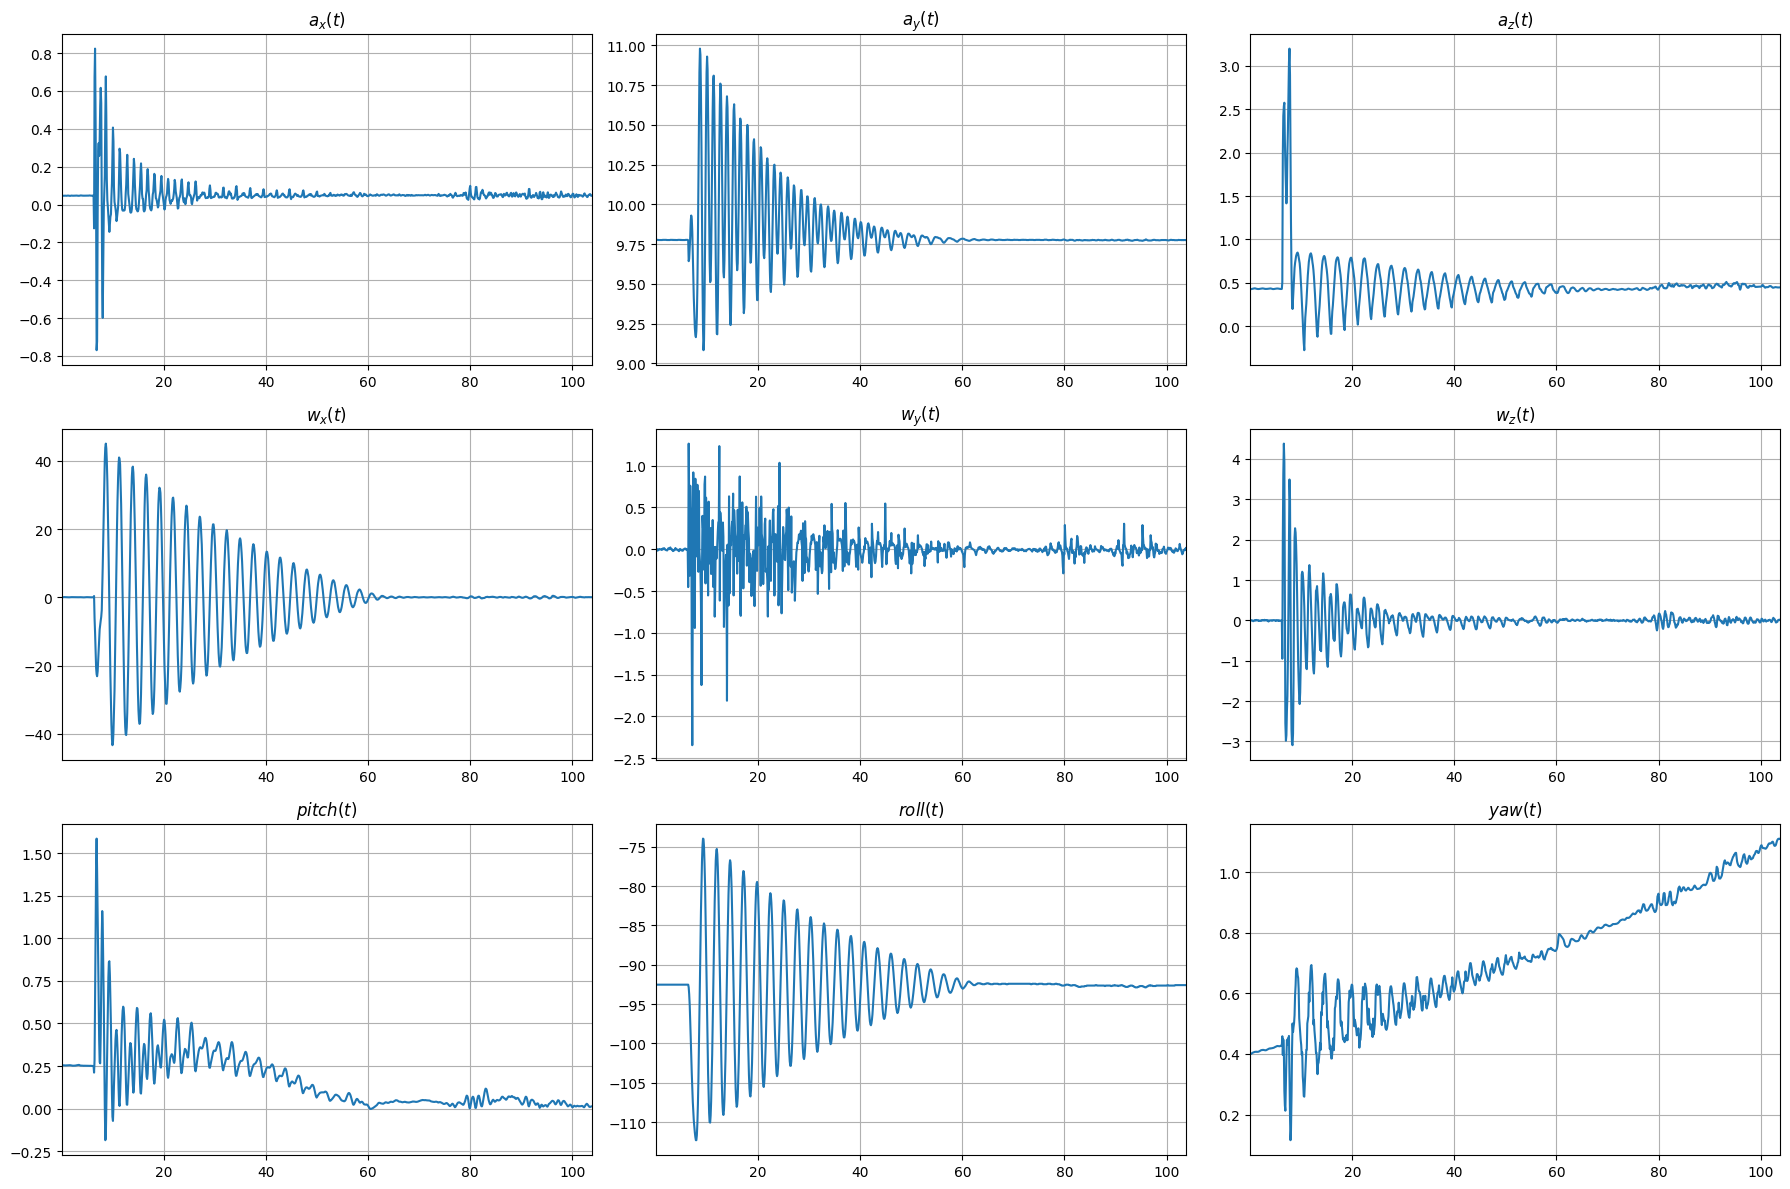

In [34]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

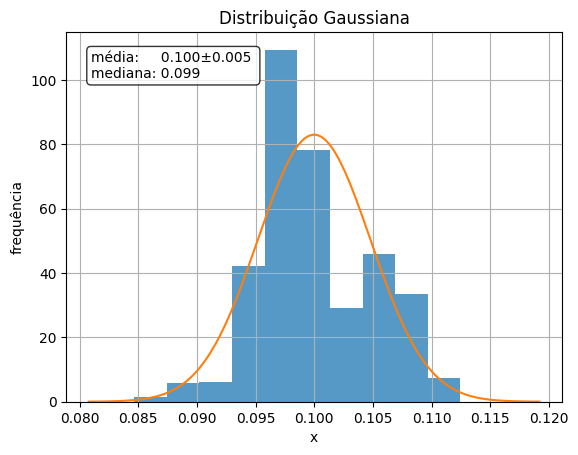

,time,pitch,q2,q1,ay,roll,yaw,ax,wy,q0,q3,az,wz,wx,sample_time,la_pos_mon_d
0,0.0,0.254622,0.000984,0.7227,9.777,-92.532684,0.399523,0.04649,-0.014066,-0.6912,-0.004016,0.4286,-0.007110,0.004141,805000000.0,0.3381
1,0.1,0.254393,0.000987,0.7227,9.777,-92.532684,0.399982,0.04615,-0.013780,-0.6912,-0.004018,0.4283,-0.006325,0.004418,905000000.0,0.3482
2,0.2,0.253992,0.000992,0.7227,9.777,-92.532684,0.400211,0.04615,0.002358,-0.6912,-0.004017,0.4278,0.003159,0.021876,5000000.0,0.3583
3,0.3,0.253763,0.001005,0.7227,9.777,-92.532684,0.401930,0.04635,-0.015791,-0.6912,-0.004026,0.4289,0.006452,0.027468,105000000.0,0.3684
4,0.4,0.253305,0.001013,0.7226,9.777,-92.532684,0.403019,0.04679,-0.010835,-0.6912,-0.004029,0.4296,-0.001793,0.055141,205000000.0,0.3785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,103.4,0.009832,0.006933,0.7229,9.776,-92.589980,1.108673,0.05456,-0.009333,-0.6909,-0.006747,0.4466,0.002871,0.041098,205000000.0,2.3000
1035,103.5,0.009614,0.006942,0.7228,9.776,-92.589980,1.109819,0.05472,-0.009649,-0.6910,-0.006754,0.4467,0.012771,0.035271,305000000.0,2.2960
1036,103.6,0.011362,0.006933,0.7228,9.776,-92.589980,1.109819,0.04937,0.000384,-0.6910,-0.006766,0.4479,0.011144,0.016696,405000000.0,2.2920
1037,103.7,0.012674,0.006927,0.7228,9.775,-92.589980,1.110392,0.04573,-0.009952,-0.6910,-0.006777,0.4474,0.019595,0.024884,505000000.0,2.2880


In [35]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [36]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,pitch,q2,q1,ay,roll,yaw,ax,wy,q0,q3,az,wz,wx,sample_time,la_pos_mon_d,static
0,0.0,0.363656,0.000744,0.7044,10.420,-89.553303,0.487587,0.01405,0.666350,-0.7098,-0.005257,0.5907,-1.061691,-36.199473,905000000.0,1.705,False
1,0.1,0.250669,0.001723,0.7269,10.590,-93.277529,0.508385,0.06104,-0.552389,-0.6867,-0.004639,0.5164,-1.150499,-37.104747,5000000.0,1.718,False
2,0.2,0.154527,0.002290,0.7488,10.630,-97.001755,0.487186,0.10020,0.467247,-0.6628,-0.003830,0.4133,-0.870896,-36.852645,105000000.0,1.723,False
3,0.3,0.091788,0.002575,0.7685,10.530,-100.439501,0.460486,0.17290,0.310371,-0.6399,-0.003188,0.3060,-0.444329,-33.512301,205000000.0,1.721,False
4,0.4,0.088064,0.002552,0.7849,10.330,-103.418882,0.442152,0.21730,0.178706,-0.6196,-0.002995,0.1947,0.159168,-28.349952,305000000.0,1.715,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,83.3,0.009832,0.006933,0.7229,9.776,-92.589980,1.108673,0.05456,-0.009333,-0.6909,-0.006747,0.4466,0.002871,0.041098,205000000.0,2.300,True
835,83.4,0.009614,0.006942,0.7228,9.776,-92.589980,1.109819,0.05472,-0.009649,-0.6910,-0.006754,0.4467,0.012771,0.035271,305000000.0,2.296,True
836,83.5,0.011362,0.006933,0.7228,9.776,-92.589980,1.109819,0.04937,0.000384,-0.6910,-0.006766,0.4479,0.011144,0.016696,405000000.0,2.292,True
837,83.6,0.012674,0.006927,0.7228,9.775,-92.589980,1.110392,0.04573,-0.009952,-0.6910,-0.006777,0.4474,0.019595,0.024884,505000000.0,2.288,True


# FILTRANDO POR VARIAVEL

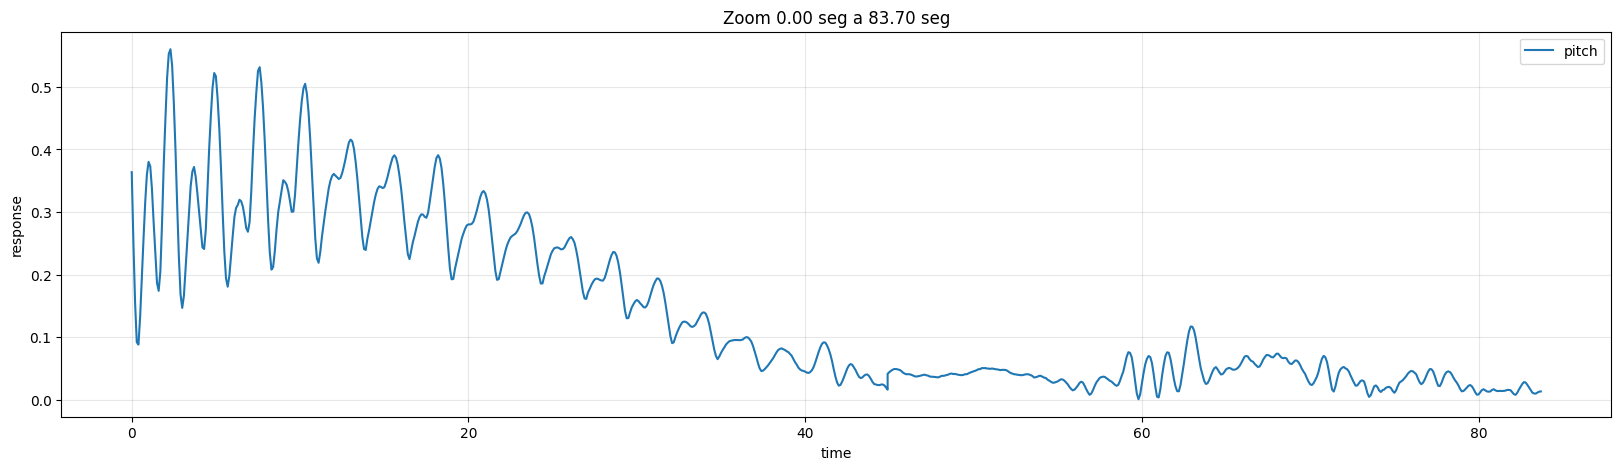

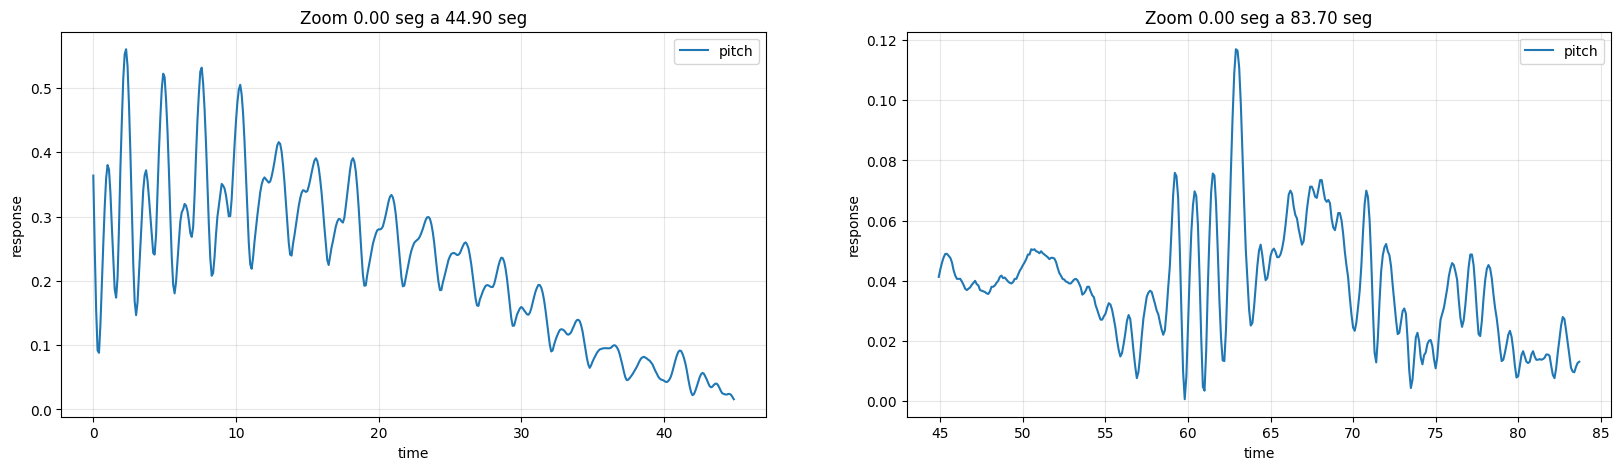

In [37]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [38]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,ref_pitch,ref_q2,ref_q1,ref_ay,ref_roll,ref_yaw,ref_ax,ref_wy,ref_q0,ref_q3,ref_az,ref_wz,ref_wx,ref_sample_time,ref_la_pos_mon_d,static
0,0.0,0.363656,0.000744,0.7044,10.420,-89.553303,0.487587,0.01405,0.666350,-0.7098,-0.005257,0.5907,-1.061691,-36.199473,905000000.0,1.705,False
1,0.1,0.250669,0.001723,0.7269,10.590,-93.277529,0.508385,0.06104,-0.552389,-0.6867,-0.004639,0.5164,-1.150499,-37.104747,5000000.0,1.718,False
2,0.2,0.154527,0.002290,0.7488,10.630,-97.001755,0.487186,0.10020,0.467247,-0.6628,-0.003830,0.4133,-0.870896,-36.852645,105000000.0,1.723,False
3,0.3,0.091788,0.002575,0.7685,10.530,-100.439501,0.460486,0.17290,0.310371,-0.6399,-0.003188,0.3060,-0.444329,-33.512301,205000000.0,1.721,False
4,0.4,0.088064,0.002552,0.7849,10.330,-103.418882,0.442152,0.21730,0.178706,-0.6196,-0.002995,0.1947,0.159168,-28.349952,305000000.0,1.715,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,83.3,0.009832,0.006933,0.7229,9.776,-92.589980,1.108673,0.05456,-0.009333,-0.6909,-0.006747,0.4466,0.002871,0.041098,205000000.0,2.300,True
835,83.4,0.009614,0.006942,0.7228,9.776,-92.589980,1.109819,0.05472,-0.009649,-0.6910,-0.006754,0.4467,0.012771,0.035271,305000000.0,2.296,True
836,83.5,0.011362,0.006933,0.7228,9.776,-92.589980,1.109819,0.04937,0.000384,-0.6910,-0.006766,0.4479,0.011144,0.016696,405000000.0,2.292,True
837,83.6,0.012674,0.006927,0.7228,9.775,-92.589980,1.110392,0.04573,-0.009952,-0.6910,-0.006777,0.4474,0.019595,0.024884,505000000.0,2.288,True


In [39]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)